# Matrix multiplication through a hand-written FFT

The transforms live in [`fft.py`](fft.py) and the product in
[`matrix_product.py`](matrix_product.py). Nothing here calls `numpy.fft` to do
the work: NumPy appears only as the oracle the results are checked against.

`A @ B` is the sum over `i` of `(column i of A)` outer `(row i of B)`. Every one
of those outer products is rank one, and the transform of a sum is the sum of
the transforms, so the product can be assembled in the frequency domain without
ever forming an outer product.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (7.5, 4), "axes.spines.top": False,
                     "axes.spines.right": False, "figure.dpi": 110})
from fft import fft_1d, fft_2d, inverse_fft_2d
from matrix_product import fast_matrix_multiplication

## The transforms agree with NumPy to machine precision

In [2]:
rng = np.random.default_rng(0)
sizes = [2, 4, 8, 16, 32, 64]
errors = {"fft_1d": [], "fft_2d": [], "inverse_fft_2d": [], "round trip": []}
for n in sizes:
    v = rng.random(n) + 1j * rng.random(n)
    m = rng.random((n, n)) + 1j * rng.random((n, n))
    errors["fft_1d"].append(np.abs(fft_1d(v) - np.fft.fft(v)).max())
    errors["fft_2d"].append(np.abs(fft_2d(m) - np.fft.fft2(m)).max())
    errors["inverse_fft_2d"].append(np.abs(inverse_fft_2d(m) - np.fft.ifft2(m)).max())
    errors["round trip"].append(np.abs(inverse_fft_2d(fft_2d(m)) - m).max())

for name, values in errors.items():
    print(f"{name:<16}" + "".join(f"{e:>10.1e}" for e in values))
print(f"{'sizes':<16}" + "".join(f"{n:>10}" for n in sizes))

fft_1d             0.0e+00   1.4e-17   2.5e-16   6.7e-16   1.1e-15   4.6e-15
fft_2d             1.1e-16   5.6e-16   4.3e-15   2.8e-14   1.1e-13   2.0e-13
inverse_fft_2d     2.8e-17   3.5e-17   6.2e-17   1.1e-16   1.1e-16   4.9e-17
round trip         1.2e-16   2.2e-16   4.0e-16   6.5e-16   1.1e-15   2.5e-15
sizes                    2         4         8        16        32        64


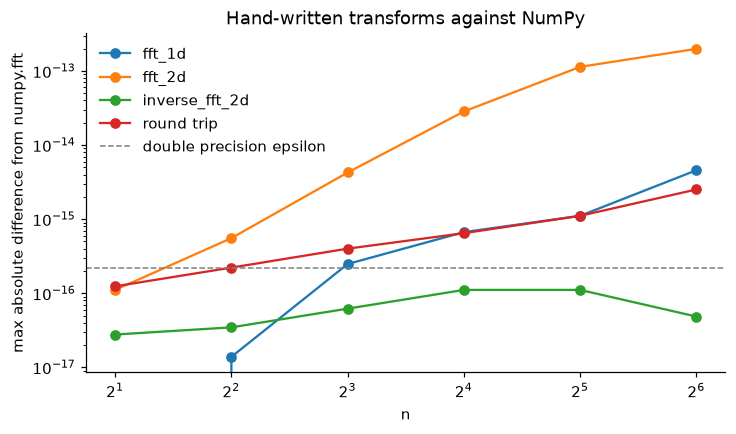

In [3]:
fig, ax = plt.subplots()
for name, values in errors.items():
    ax.plot(sizes, values, marker="o", label=name)
ax.set_xscale("log", base=2); ax.set_yscale("log")
ax.set_xlabel("n"); ax.set_ylabel("max absolute difference from numpy.fft")
ax.set_title("Hand-written transforms against NumPy")
ax.axhline(2.2e-16, ls="--", c="grey", lw=1, label="double precision epsilon")
ax.legend(frameon=False)
fig.savefig("fft_accuracy.png", dpi=110, bbox_inches="tight")  # used by the project page
plt.show()

## Radix-2 refuses sizes it cannot handle

An earlier version demonstrated the 1D transform on a length-7 input. Radix-2
has nothing to say about 7, and the result was a half-filled array whose only
correct entry was the DC term. It now raises instead.

In [4]:
for bad in (3, 7, 12):
    try:
        fft_1d(np.ones(bad))
    except ValueError as error:
        print(f"n={bad}: {error}")

n=3: input length must be a power of two, got 3
n=7: input length must be a power of two, got 7
n=12: input length must be a power of two, got 12


## The product itself

In [5]:
A = np.array([[1, 10, 33, 2], [3, 4, 34, 6], [34, 76, 87, 99], [90, 75, 45, 0]])
B = np.array([[55, 67, 88, 6], [70, 12, 32, 8], [23, 98, 89, 11], [21, 44, 55, 66]])
computed = fast_matrix_multiplication(A, B)
print("through the hand-written transforms:")
print(np.round(computed.real).astype(int))
print("\nA @ B:")
print(A @ B)
print(f"\nmax absolute difference: {np.abs(computed - A @ B).max():.2e}")

through the hand-written transforms:
[[ 1556  3509  3455   581]
 [ 1353  3845  3748   820]
 [11270 16072 18612  8303]
 [11235 11340 14325  1635]]

A @ B:
[[ 1556  3509  3455   581]
 [ 1353  3845  3748   820]
 [11270 16072 18612  8303]
 [11235 11340 14325  1635]]

max absolute difference: 3.85e-13


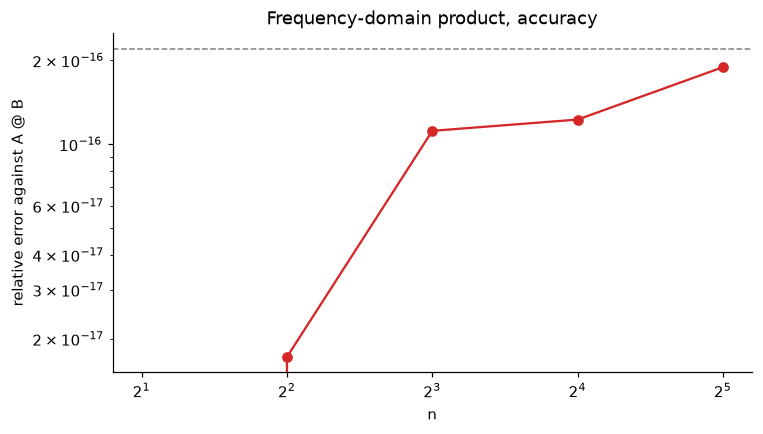

In [6]:
rel = []
for n in sizes[:5]:
    a, b = rng.integers(0, 50, (n, n)), rng.integers(0, 50, (n, n))
    rel.append(np.abs(fast_matrix_multiplication(a, b) - a @ b).max() / np.abs(a @ b).max())
fig, ax = plt.subplots()
ax.plot(sizes[:5], rel, marker="o", color="#d62728")
ax.set_xscale("log", base=2); ax.set_yscale("log")
ax.set_xlabel("n"); ax.set_ylabel("relative error against A @ B")
ax.set_title("Frequency-domain product, accuracy")
ax.axhline(2.2e-16, ls="--", c="grey", lw=1)
plt.show()

## What this is and is not

It is a demonstration of the identity, not a fast multiplication. Carrying two
vector families down the recursion costs more than `A @ B`, and the constant
factors of a hand-written Python transform are far worse than a BLAS call. The
interest is that the product never has to be formed in the spatial domain.